# CO2 Emissions Analysis — KMeans Clustering
## York University — Big Data Analytics Certificate (2024)

**Author:** Lalita  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
**Dataset:** CO2 Emissions Canada — 7,385 vehicles  

---

## Project Overview
This project analyzes Canadian vehicle CO2 emissions data 
using KMeans Clustering to identify distinct vehicle groups 
based on engine size, cylinders and CO2 emissions.

## Key Findings
| Cluster | Vehicle Type | Avg Engine | Avg CO2 |
|---|---|---|---|
| Cluster 0 | Low Emission | 2.0 L | 202.9 g/km |
| Cluster 1 | Medium Emission | 3.4 L | 263.7 g/km |
| Cluster 2 | High Emission | 5.3 L | 330.5 g/km |

## Conclusion
Larger engine size strongly correlates with higher CO2 
emissions. KMeans clustering successfully identified 3 
distinct vehicle emission groups from 7,385 Canadian 
government vehicle records.

---
🔗 **Kaggle Profile:** kaggle.com/lalitacanada  
🎓 **York University — Big Data Analytics (2024)**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/kaggle/input/datasets/debajyotipodder/co2-emission-by-vehicles/CO2 Emissions_Canada.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (7385, 12)
    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2 

In [10]:
# Check column names and data types
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Columns: ['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']

Missing values:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

Basic Statistics:
       Engine Size(L)    Cylinders  Fuel Consumption City (L/100 km)  \
count     7385.000000  7385.000000                       7385.000000   
mean         3.160068     5.615030                         12.556534   
std          1

In [11]:
# Select features for clustering
features = df[['Engine Size(L)', 'Cylinders', 'CO2 Emissions(g/km)']]

# Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Apply KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled)

# Renumber clusters by average CO2 so 0 = Low, 1 = Medium, 2 = High
order = df['CO2 Emissions(g/km)'].groupby(labels).mean().sort_values().index
mapping = {old: new for new, old in enumerate(order)}
df['Cluster'] = pd.Series(labels).map(mapping).values

print("Cluster counts:")
print(df['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    3282
1    2562
2    1541
Name: count, dtype: int64


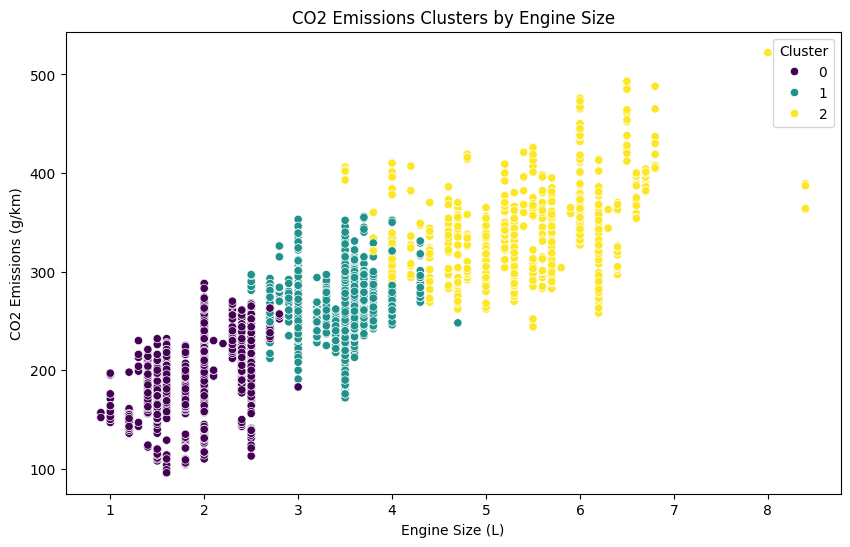

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,
                x='Engine Size(L)',
                y='CO2 Emissions(g/km)',
                hue='Cluster',
                palette='viridis')
plt.title('CO2 Emissions Clusters by Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend(title='Cluster')
plt.show()

/tmp/ipykernel_57/3335726688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


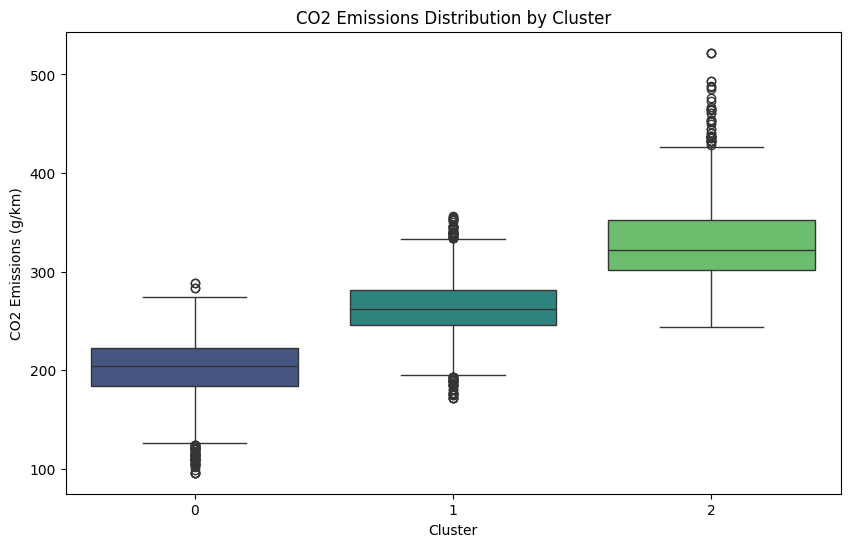

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            x='Cluster',
            y='CO2 Emissions(g/km)',
            palette='viridis')
plt.title('CO2 Emissions Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

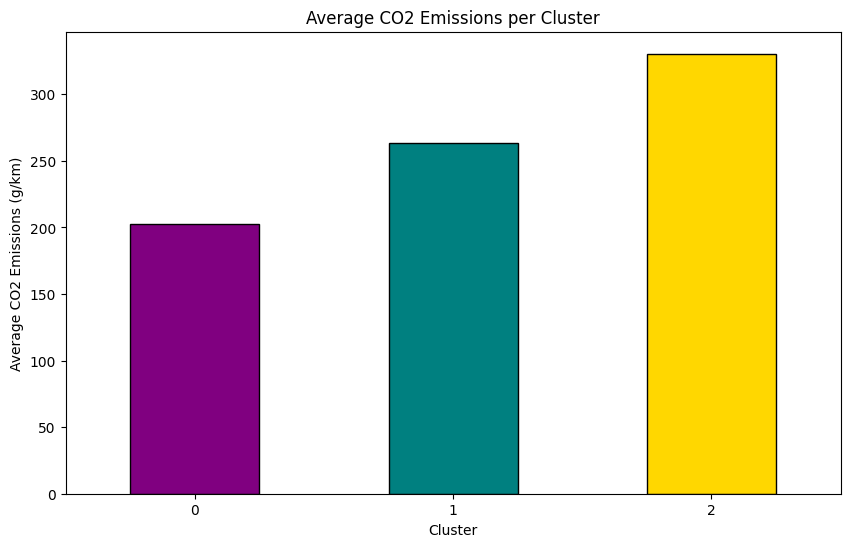

In [14]:
plt.figure(figsize=(10,6))
cluster_means = df.groupby('Cluster')['CO2 Emissions(g/km)'].mean()
cluster_means.plot(kind='bar', 
                   color=['purple', 'teal', 'gold'],
                   edgecolor='black')
plt.title('Average CO2 Emissions per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average CO2 Emissions (g/km)')
plt.xticks(rotation=0)
plt.show()

In [15]:
print("=" * 50)
print("KEY INSIGHTS — CO2 Emissions Analysis")
print("=" * 50)

print(f"\nTotal vehicles analyzed: {len(df)}")
print("Total clusters identified: 3")

print("\nCluster Summary:")
summary = df.groupby('Cluster')[['Engine Size(L)', 'Cylinders', 'CO2 Emissions(g/km)']].mean().round(2)
print(summary)

names = {0: 'Low Emission', 1: 'Medium Emission', 2: 'High Emission'}
print("\nKey Findings:")
for k in range(3):
    group = df[df['Cluster'] == k]
    print(f"\nCluster {k} — {names[k]} Vehicles ({len(group)} vehicles):")
    print(f"  Avg CO2: {group['CO2 Emissions(g/km)'].mean():.1f} g/km")
    print(f"  Avg Engine Size: {group['Engine Size(L)'].mean():.1f} L")

print("\nConclusion:")
print("Larger engine size strongly correlates with higher CO2 emissions.")
print("KMeans clustering identified 3 distinct vehicle emission groups.")

KEY INSIGHTS — CO2 Emissions Analysis

Total vehicles analyzed: 7385
Total clusters identified: 3

Cluster Summary:
         Engine Size(L)  Cylinders  CO2 Emissions(g/km)
Cluster                                                
0                  1.98       3.98               202.86
1                  3.37       6.01               263.67
2                  5.33       8.45               330.47

Key Findings:

Cluster 0 — Low Emission Vehicles (3282 vehicles):
  Avg CO2: 202.9 g/km
  Avg Engine Size: 2.0 L

Cluster 1 — Medium Emission Vehicles (2562 vehicles):
  Avg CO2: 263.7 g/km
  Avg Engine Size: 3.4 L

Cluster 2 — High Emission Vehicles (1541 vehicles):
  Avg CO2: 330.5 g/km
  Avg Engine Size: 5.3 L

Conclusion:
Larger engine size strongly correlates with higher CO2 emissions.
KMeans clustering identified 3 distinct vehicle emission groups.
